In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import sys, os
sys.path.append("..")
from data_fetchers.worldbank_fetcher import fetch_all_mvp

In [3]:
df = fetch_all_mvp()
df = df.set_index("year")
print(df.head())

df.info()
df.describe()

      gdp_growth   inflation  unemployment  poverty
year                                               
1960         NaN   39.590444           NaN      NaN
1961    5.740646   13.691932           NaN      NaN
1962    1.841978  131.397849           NaN      NaN
1963   -2.237030  145.910781           NaN      NaN
1964    3.529698  108.994709           NaN      NaN
<class 'pandas.DataFrame'>
RangeIndex: 66 entries, 1960 to 2025
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   gdp_growth    65 non-null     float64
 1   inflation     66 non-null     float64
 2   unemployment  35 non-null     float64
 3   poverty       27 non-null     float64
dtypes: float64(4)
memory usage: 2.2 KB


,gdp_growth,inflation,unemployment,poverty
count,65.000000,66.000000,35.000000,27.000000
mean,5.109235,40.776638,4.961429,13.733333
std,3.302576,144.982620,1.550677,3.900592
min,-13.126725,1.560079,2.617000,9.000000
25%,4.699879,5.472703,3.805000,10.350000
50%,5.500952,8.905326,4.514000,12.500000
75%,6.911983,15.032891,6.094000,17.050000
max,10.915179,1136.254112,8.060000,23.400000


mean = 40.78%, tapi median (50%) = 8.9%, max = 1136%, std 145! Mean dan median yang
  berjauhan = outlier ekstrem mendominasi. Max 1136% itu hiperinflasi 1960-an
Implikasinya: untuk menganalisis inflasi "normal", Anda harus filter ke era modern
  (mis. ≥ 2000). Juga cek gdp_growth min -13.1% = krisis moneter 1998 (kontraksi PDB Indonesia saat itu memang ~13%) —
  anomali nyata lain.

In [4]:
df.isna().sum()

gdp_growth       1
inflation        0
unemployment    31
poverty         39
dtype: int64

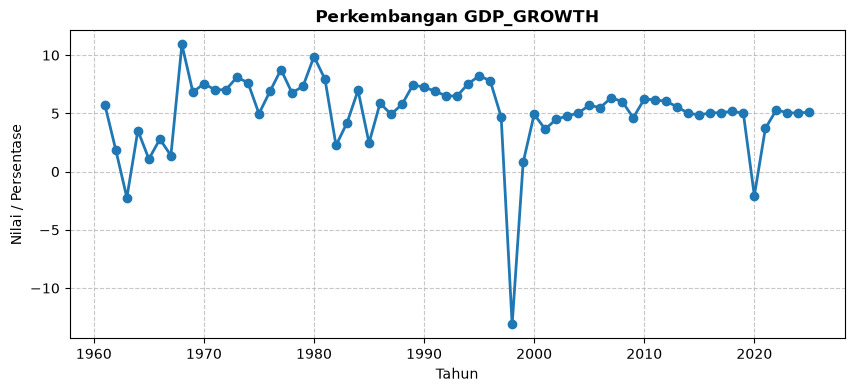

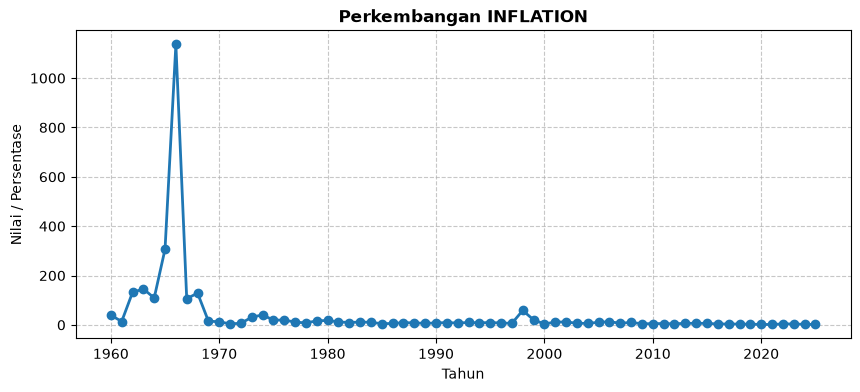

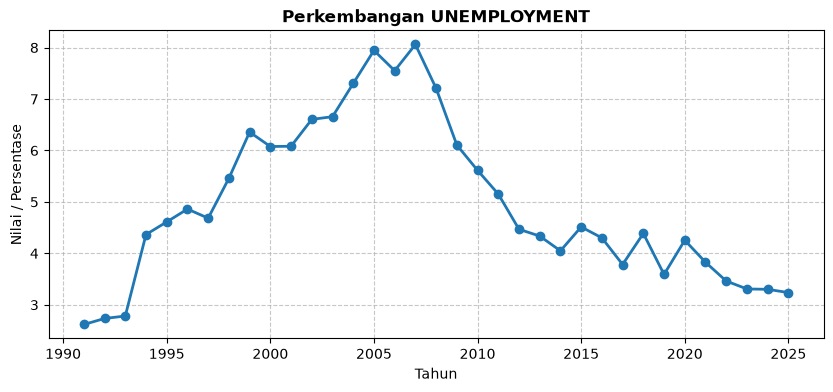

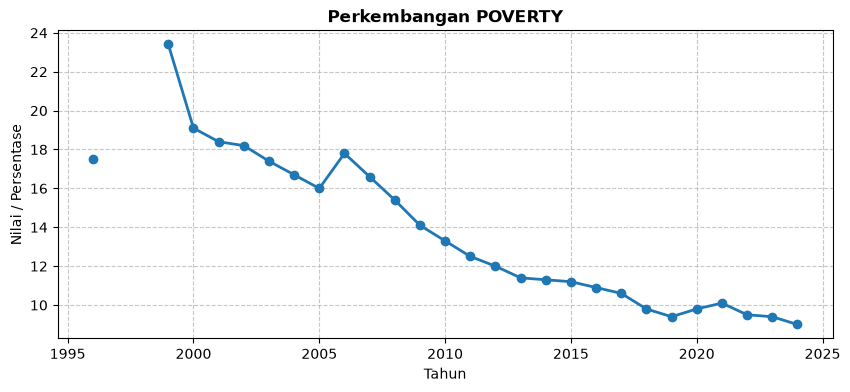

In [5]:

indikator_list = [kolom for kolom in df.columns]

for indikator in indikator_list:
    
    plt.figure(figsize=(10, 4))
    
    plt.plot(df.index, df[indikator], marker="o", linewidth=2, color="tab:blue")
    
    plt.title(f"Perkembangan {indikator.upper()}", fontsize=12, fontweight="bold")
    plt.xlabel("Tahun")
    plt.ylabel("Nilai / Persentase")
    plt.grid(True, linestyle="--", alpha=0.7)
    
    plt.show()

Tabel Korelasi:
              gdp_growth  inflation  unemployment   poverty
gdp_growth      1.000000  -0.184629     -0.087275 -0.031121
inflation      -0.184629   1.000000      0.230443  0.803803
unemployment   -0.087275   0.230443      1.000000  0.796683
poverty        -0.031121   0.803803      0.796683  1.000000


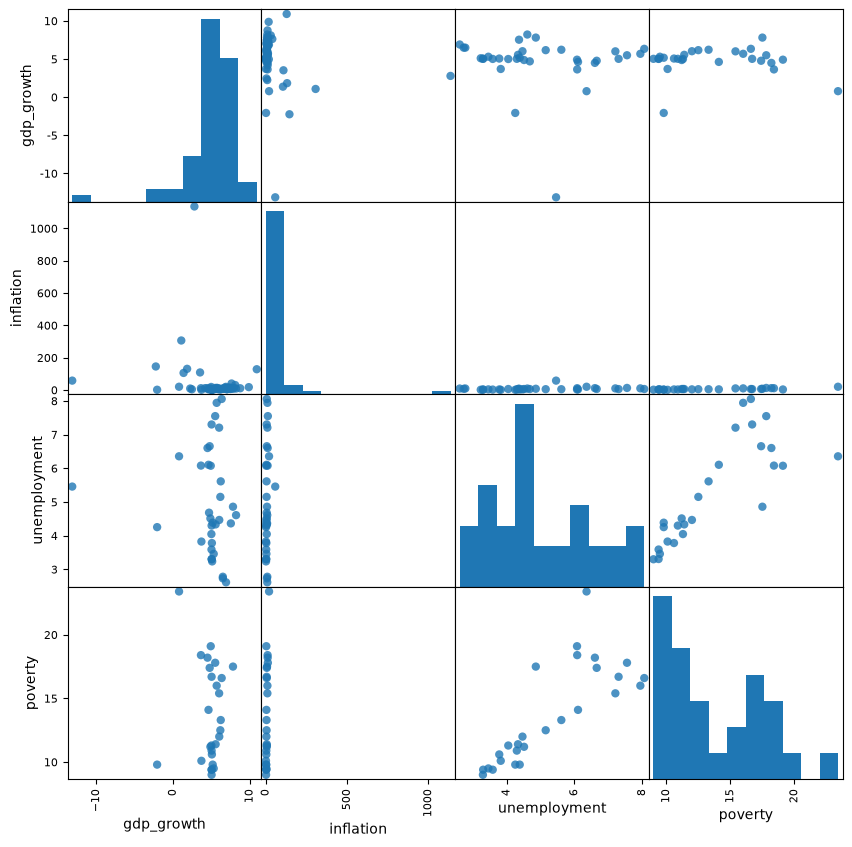

In [ ]:
print("Tabel Korelasi:")
print(df.corr())

pd.plotting.scatter_matrix(
    df, 
    figsize=(10, 10), 
    marker="o", 
    alpha=0.8,      # Membuat titik sedikit transparan agar tumpukan data terlihat
    diagonal="hist"
)

plt.show()

In [12]:
df_modern = df[df.index >= 2000]
print(df_modern.head())

df_modern.info()
df_modern.describe()


      gdp_growth  inflation  unemployment  poverty
year                                              
2000    4.920068   3.688620         6.077     19.1
2001    3.643466  11.500116         6.082     18.4
2002    4.499475  11.900120         6.604     18.2
2003    4.780369   6.757313         6.657     17.4
2004    5.030874   6.064062         7.303     16.7
<class 'pandas.DataFrame'>
RangeIndex: 26 entries, 2000 to 2025
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   gdp_growth    26 non-null     float64
 1   inflation     26 non-null     float64
 2   unemployment  26 non-null     float64
 3   poverty       25 non-null     float64
dtypes: float64(4)
memory usage: 964.0 bytes


,gdp_growth,inflation,unemployment,poverty
count,26.000000,26.000000,26.000000,25.000000
mean,4.898070,5.671123,5.199154,13.196000
std,1.569515,3.271823,1.578822,3.420097
min,-2.065512,1.560079,3.237000,9.000000
25%,4.887259,3.561700,3.882500,10.100000
50%,5.040950,4.760310,4.491000,12.000000
75%,5.543186,6.411011,6.479500,16.600000
max,6.345022,13.108671,8.060000,19.100000


In [11]:
df_modern.isna().sum()

gdp_growth      0
inflation       0
unemployment    0
poverty         1
dtype: int64

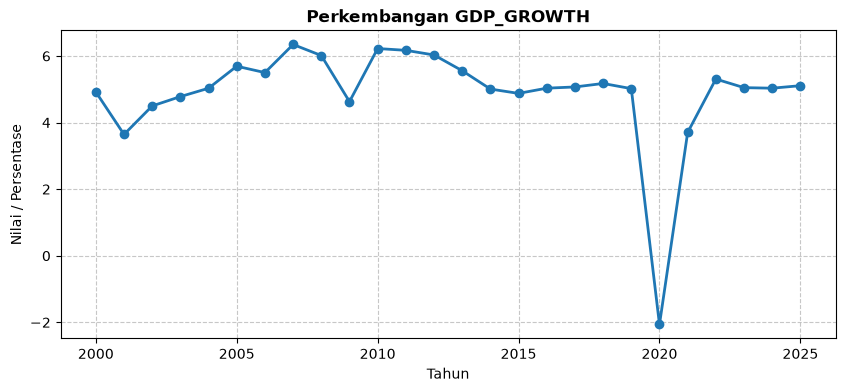

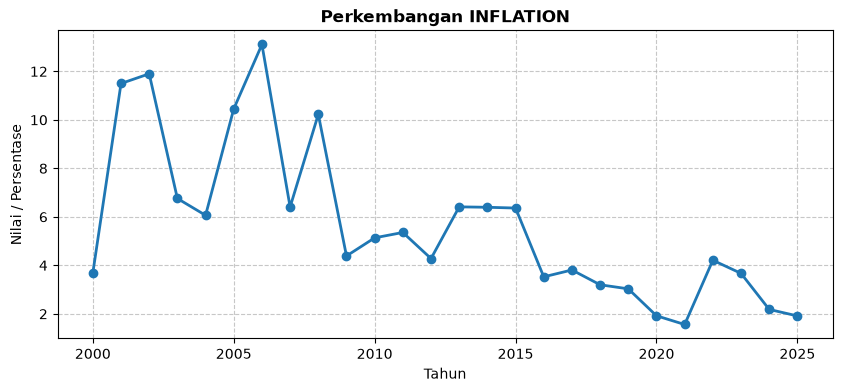

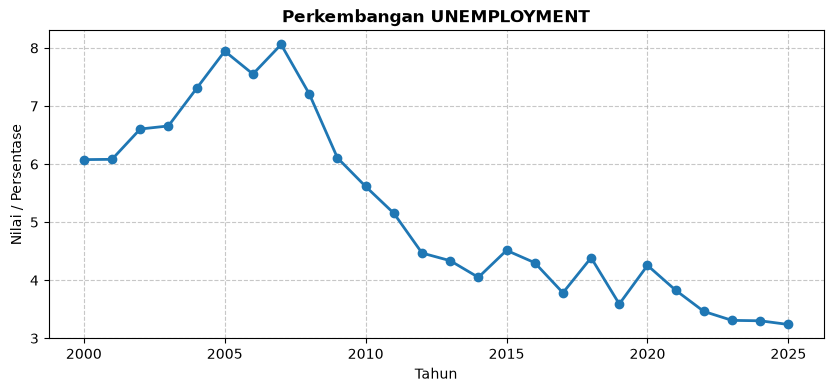

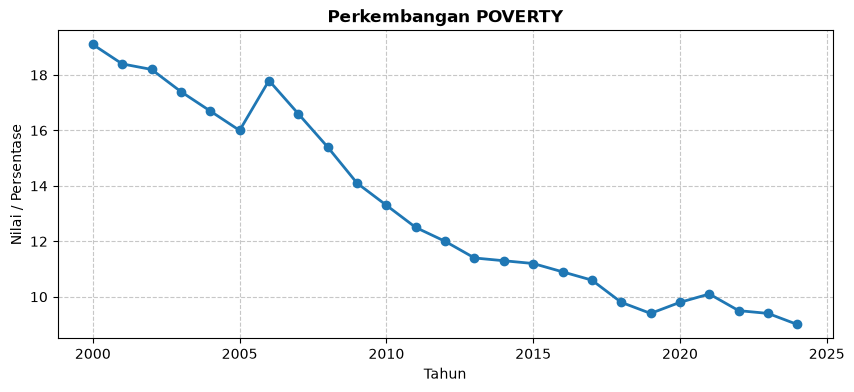

In [13]:

indikator_list = [kolom for kolom in df_modern.columns]

for indikator in indikator_list:
    
    plt.figure(figsize=(10, 4))
    
    plt.plot(df_modern.index, df_modern[indikator], marker="o", linewidth=2, color="tab:blue")
    
    plt.title(f"Perkembangan {indikator.upper()}", fontsize=12, fontweight="bold")
    plt.xlabel("Tahun")
    plt.ylabel("Nilai / Persentase")
    plt.grid(True, linestyle="--", alpha=0.7)
    
    plt.show()

Tabel Korelasi:
              gdp_growth  inflation  unemployment   poverty
gdp_growth      1.000000   0.233604      0.209005  0.173617
inflation       0.233604   1.000000      0.731519  0.727327
unemployment    0.209005   0.731519      1.000000  0.887032
poverty         0.173617   0.727327      0.887032  1.000000


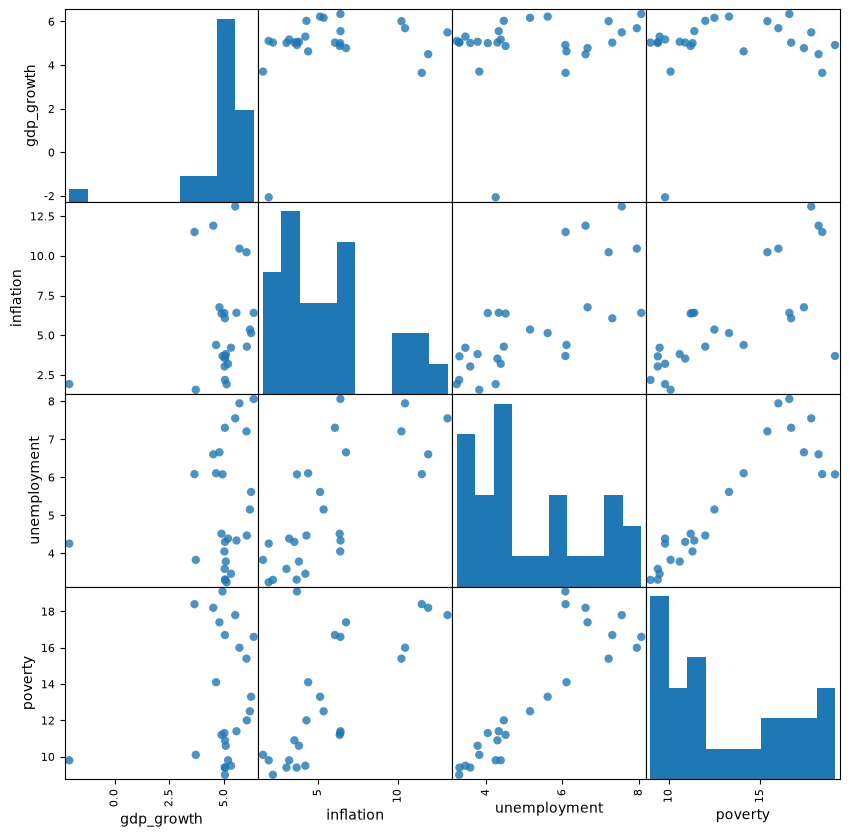

In [ ]:
print("Tabel Korelasi:")
print(df_modern.corr())

pd.plotting.scatter_matrix(
    df_modern, 
    figsize=(10, 10), 
    marker="o", 
    alpha=0.8,      # Membuat titik sedikit transparan agar tumpukan data terlihat
    diagonal="hist" 
)

plt.show()